In [1]:
# =============================================================================
# PROJET : ANALYSE & PRÉVISION DES RECETTES FISCALES GENEVOISES
# Notebook : 02_tests.ipynb
# Auteur   : Frat DAG
# Date     : Avril 2026
# Version  : 2.0 — approche inductive (traduction Python du script R)
# =============================================================================
# CE QU'ON SAIT APRÈS LE NOTEBOOK 01 :
#   - Tendance haussière portée par ben_pm et ifd — pas par l'IR
#   - L'IR décroît nominalement (Q7 — artefact nomenclature 2012)
#   - Fortune : corrélation spurieuse (0.86 → 0.05 en différences)
#   - Ruptures visuelles : 2010, 2020, 2022
#   - Outlier successions 2009 (308M vs médiane 188M)
#
# QUESTIONS À TRAITER — DANS CET ORDRE :
#   Q7 — Rupture nomenclature IR (prérequis à Q1)
#   Q1 — Stationnarité ADF + PP + KPSS
#   Q1B — Zivot-Andrews (rupture endogène)
#   Q2 — Ruptures structurelles Chow
#   Q3 — Outlier successions 2009
#   Q4 — Cointégration Johansen
#   Q5 — Corrélations en différences
#   Q6 — Dummy RFFA testée formellement
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Créer dossiers si nécessaire
for dossier in ['../data', '../figures']:
    os.makedirs(dossier, exist_ok=True)

# Chargement des données du notebook 01
df = pd.read_csv('../data/df_fiscal.csv')

print(f"✓ Données chargées : {len(df)} observations, {len(df.columns)} variables")
print(f"  Période : {df['annee'].min()}–{df['annee'].max()}")
print(f"\nColonnes disponibles :")
print(list(df.columns))

✓ Données chargées : 18 observations, 21 variables
  Période : 2007–2024

Colonnes disponibles :
['annee', 'pp_total', 'ir', 'fortune', 'pm_total', 'ben_pm', 'cap_pm', 'enreg_timbre', 'successions', 'ifd', 'total', 'pib_ge', 'saron', 'ipc', 'var_total', 'var_total_p', 'var_ben_pm', 'var_ifd', 'dummy_rffa', 'dummy_covid', 'dummy_succ_2009']


In [2]:
# =============================================================================
# Q7 — RUPTURE DE NOMENCLATURE DANS L'IR
# =============================================================================
# Prérequis à Q1 : vérifier que la série IR est comparable sur toute la période
# En 2012, l'OCSTAT a séparé les impôts à la source de l'IR.
# =============================================================================

print("=" * 60)
print("Q7 — RUPTURE DE NOMENCLATURE DANS L'IR")
print("=" * 60)

# Impôts à la source disponibles depuis 2012
source_imp = [np.nan]*5 + [757,721,597,726,722,741,786,796,810,1003,1484,1097,1282]
df['source_imp'] = source_imp
df['ir_corrige'] = np.where(df['source_imp'].notna(),
                             df['ir'] + df['source_imp'],
                             df['ir'])

print(f"\nIR seul 2007–2011 (moyenne)    : {df.loc[df['annee']<=2011,'ir'].mean():.0f}M")
print(f"IR seul 2012–2024 (moyenne)    : {df.loc[df['annee']>=2012,'ir'].mean():.0f}M")
print(f"IR corrigé 2012–2024 (moyenne) : {df.loc[df['annee']>=2012,'ir_corrige'].mean():.0f}M")
print(f"PP total 2007–2024 (moyenne)   : {df['pp_total'].mean():.0f}M")

print("\n# DÉCISION Q7 :")
print("# La baisse de l'IR est un artefact de nomenclature OCSTAT 2012.")
print("# On utilise pp_total comme proxy cohérent sur 2007–2024.")

# =============================================================================
# Q1 — TESTS DE STATIONNARITÉ (ADF + PP + KPSS)
# =============================================================================
# Avec N=18, la puissance des tests est faible.
# On triangule trois tests pour robustesse.
# =============================================================================

print("\n" + "=" * 60)
print("Q1 — TESTS DE STATIONNARITÉ")
print("=" * 60)
print("\n⚠️  LIMITE : N=18 → puissance faible.")
print("    Les tests sont des guides, pas des verdicts.\n")

series_test = {
    'Total recettes' : df['total'].values,
    'PP total'       : df['pp_total'].values,
    'Bénéfice PM'    : df['ben_pm'].values,
    'Fortune PP'     : df['fortune'].values,
    'IFD'            : df['ifd'].values,
    'Enreg. timbre'  : df['enreg_timbre'].values
}

resultats = []

for nom, serie in series_test.items():
    # ADF en niveau
    adf_niv  = adfuller(serie, maxlag=1, autolag=None)
    # ADF en différence
    adf_diff = adfuller(np.diff(serie), maxlag=1, autolag=None)
    # KPSS en niveau
    kpss_niv = kpss(serie, regression='ct', nlags='auto')
    # KPSS en différence
    kpss_dif = kpss(np.diff(serie), regression='c', nlags='auto')

    i1 = adf_niv[1] > 0.05 and adf_diff[1] < 0.05
    decision = "I(1)" if i1 else "Ambigu"

    print(f"--- {nom} ---")
    print(f"  ADF niveau    : p = {adf_niv[1]:.3f} "
          f"{'→ non stationnaire' if adf_niv[1]>0.05 else '→ stationnaire'}")
    print(f"  ADF diff 1ère : p = {adf_diff[1]:.3f} "
          f"{'→ stationnaire' if adf_diff[1]<0.05 else '→ non stationnaire'}")
    print(f"  KPSS niveau   : p = {kpss_niv[1]:.3f} "
          f"{'→ non stationnaire' if kpss_niv[1]<0.05 else '→ stationnaire'}")
    print(f"  KPSS diff     : p = {kpss_dif[1]:.3f} "
          f"{'→ stationnaire' if kpss_dif[1]>0.05 else '→ non stationnaire'}")
    print(f"  → DÉCISION : {decision}\n")

    resultats.append({
        'Serie'      : nom,
        'ADF_niv_p'  : round(adf_niv[1], 3),
        'ADF_diff_p' : round(adf_diff[1], 3),
        'KPSS_niv_p' : round(kpss_niv[1], 3),
        'KPSS_dif_p' : round(kpss_dif[1], 3),
        'Decision'   : decision
    })

tableau_station = pd.DataFrame(resultats)
print("=== TABLEAU DE SYNTHÈSE ===")
print(tableau_station.to_string(index=False))

print("\n# DÉCISION Q1 :")
print("# Séries fiscales principales : I(1)")
print("# On travaille sur les différences premières dans le notebook 03.")

Q7 — RUPTURE DE NOMENCLATURE DANS L'IR

IR seul 2007–2011 (moyenne)    : 3186M
IR seul 2012–2024 (moyenne)    : 2731M
IR corrigé 2012–2024 (moyenne) : 3617M
PP total 2007–2024 (moyenne)   : 4135M

# DÉCISION Q7 :
# La baisse de l'IR est un artefact de nomenclature OCSTAT 2012.
# On utilise pp_total comme proxy cohérent sur 2007–2024.

Q1 — TESTS DE STATIONNARITÉ

⚠️  LIMITE : N=18 → puissance faible.
    Les tests sont des guides, pas des verdicts.

--- Total recettes ---
  ADF niveau    : p = 0.945 → non stationnaire
  ADF diff 1ère : p = 0.014 → stationnaire
  KPSS niveau   : p = 0.032 → non stationnaire
  KPSS diff     : p = 0.100 → stationnaire
  → DÉCISION : I(1)

--- PP total ---
  ADF niveau    : p = 0.992 → non stationnaire
  ADF diff 1ère : p = 0.007 → stationnaire
  KPSS niveau   : p = 0.010 → non stationnaire
  KPSS diff     : p = 0.042 → non stationnaire
  → DÉCISION : I(1)

--- Bénéfice PM ---
  ADF niveau    : p = 0.771 → non stationnaire
  ADF diff 1ère : p = 0.012 → sta

In [6]:
# =============================================================================
# Q1B — TEST DE ZIVOT-ANDREWS (rupture endogène)
# =============================================================================
# Identifie endogènement le point de rupture le plus probable.
# H0 : racine unitaire sans rupture
# H1 : stationnaire avec rupture à un point inconnu
# =============================================================================

# =============================================================================
# Q1B — TEST DE ZIVOT-ANDREWS (rupture endogène)
# =============================================================================

print("=" * 60)
print("Q1B — TEST DE ZIVOT-ANDREWS")
print("=" * 60)
print("\nPOURQUOI : identifie endogènement le point de rupture")
print("sans présupposer la date — plus robuste sur petit N.")
print("⚠️  Note : regression='c' utilisée (contrainte N=18)\n")

from statsmodels.tsa.stattools import zivot_andrews

za_crit = {'1%': -5.34, '5%': -4.80, '10%': -4.58}

series_za = {
    'Total recettes' : df['total'].values,
    'Bénéfice PM'    : df['ben_pm'].values,
    'IFD'            : df['ifd'].values
}

for nom, serie in series_za.items():
    try:
        za       = zivot_andrews(serie, regression='c')
        stat     = za[0]
        pval     = za[1]
        bp       = za[4]
        annee_bp = 2007 + int(bp)
        crit_5   = za_crit['5%']

        print(f"--- {nom} ---")
        print(f"  Stat           : {stat:.4f}")
        print(f"  Valeur crit 5% : {crit_5:.2f}")
        print(f"  p-value        : {pval:.4f}")
        print(f"  Rupture        : position {int(bp)} → année {annee_bp}")
        rejet = stat < crit_5
        print(f"  → {'Rejet H0 ✓' if rejet else 'Non rejet — racine unitaire'}\n")

    except Exception as e:
        print(f"--- {nom} ---")
        print(f"  ⚠️  Erreur : {e}\n")

print("# DÉCISION Q1B :")
print("# Résultats indicatifs sur N=18.")
print("# Les conclusions du script R (ur.za) restent la référence.")
print("# Position de rupture à interpréter avec prudence.")
# =============================================================================
# Q2 — TEST DE CHOW — RUPTURES STRUCTURELLES
# =============================================================================
# H0 : pas de rupture | H1 : rupture au point testé
# On teste : 2010 (crise), 2020 (COVID)
# 2022 non testable : N post-rupture = 3 observations
# =============================================================================

print("\n" + "=" * 60)
print("Q2 — TEST DE CHOW — RUPTURES STRUCTURELLES")
print("=" * 60)
print("\nPOURQUOI : valider formellement les ruptures visuelles.\n")

from scipy.stats import f as fdist

def chow_test(y, x, breakpoint_idx):
    """
    Test de Chow manuel.
    y : variable dépendante
    x : variable explicative (tendance)
    breakpoint_idx : index de la rupture
    """
    n = len(y)
    # Régression complète
    X_full = np.column_stack([np.ones(n), x])
    beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0]
    rss_full = np.sum((y - X_full @ beta_full)**2)

    # Régression avant rupture
    y1, x1 = y[:breakpoint_idx], x[:breakpoint_idx]
    X1 = np.column_stack([np.ones(len(y1)), x1])
    beta1 = np.linalg.lstsq(X1, y1, rcond=None)[0]
    rss1 = np.sum((y1 - X1 @ beta1)**2)

    # Régression après rupture
    y2, x2 = y[breakpoint_idx:], x[breakpoint_idx:]
    X2 = np.column_stack([np.ones(len(y2)), x2])
    beta2 = np.linalg.lstsq(X2, y2, rcond=None)[0]
    rss2 = np.sum((y2 - X2 @ beta2)**2)

    k = 2  # nombre de paramètres
    rss_restricted = rss1 + rss2
    f_stat = ((rss_full - rss_restricted) / k) / (rss_restricted / (n - 2*k))
    p_val = 1 - fdist.cdf(f_stat, k, n - 2*k)

    return f_stat, p_val

y = df['total'].values
x = np.arange(1, len(y)+1, dtype=float)

resultats_chow = []
for annee_test in [2010, 2020]:
    idx = df[df['annee'] == annee_test].index[0]
    f_stat, p_val = chow_test(y, x, idx)
    conclusion = "Confirmée ✓" if p_val < 0.05 else "Non confirmée"
    print(f"Rupture {annee_test} : F = {f_stat:.3f} | p = {p_val:.3f} "
          f"→ {conclusion}")
    resultats_chow.append({
        'Annee'     : annee_test,
        'F_stat'    : round(f_stat, 3),
        'p_value'   : round(p_val, 3),
        'Conclusion': conclusion
    })

print("\nRupture 2022 : test de Chow inadmissible")
print("  → N post-rupture = 3 observations — insuffisant")
print("  → Traitée via dummy_rffa en Q6")

resultats_chow.append({
    'Annee'     : 2022,
    'F_stat'    : None,
    'p_value'   : None,
    'Conclusion': 'Non testable — dummy_rffa en Q6'
})

print("\n=== TABLEAU CHOW ===")
print(pd.DataFrame(resultats_chow).to_string(index=False))

print("\n# DÉCISION Q2 :")
print("# 2010 et 2020 : ruptures confirmées statistiquement.")
print("# 2022 : traitée via dummy_rffa en Q6.")

Q1B — TEST DE ZIVOT-ANDREWS

POURQUOI : identifie endogènement le point de rupture
sans présupposer la date — plus robuste sur petit N.
⚠️  Note : regression='c' utilisée (contrainte N=18)

--- Total recettes ---
  Stat           : -4.7601
  Valeur crit 5% : -4.80
  p-value        : 0.0594
  Rupture        : position 14 → année 2021
  → Non rejet — racine unitaire

--- Bénéfice PM ---
  ⚠️  Erreur : ZA: auxiliary exog matrix is not full rank.
  cols (exc intercept) = 5  rank = 4.0

--- IFD ---
  ⚠️  Erreur : Singular matrix

# DÉCISION Q1B :
# Résultats indicatifs sur N=18.
# Les conclusions du script R (ur.za) restent la référence.
# Position de rupture à interpréter avec prudence.

Q2 — TEST DE CHOW — RUPTURES STRUCTURELLES

POURQUOI : valider formellement les ruptures visuelles.

Rupture 2010 : F = 3.970 | p = 0.043 → Confirmée ✓
Rupture 2020 : F = 18.687 | p = 0.000 → Confirmée ✓

Rupture 2022 : test de Chow inadmissible
  → N post-rupture = 3 observations — insuffisant
  → Traitée

## ⚠️ Note — Zivot-Andrews : Python vs R

Le test de Zivot-Andrews de `statsmodels` échoue sur `ben_pm` et `ifd` 
avec N=18 — matrice auxiliaire singulière due au manque de degrés de liberté.

Le package `urca` de R (`ur.za`) gère mieux ce cas grâce à une 
implémentation plus robuste du modèle auxiliaire.

**Conclusions de référence — script R `02_tests.R` :**

| Série | Stat | Crit 5% | Rupture détectée | Décision |
|-------|------|---------|-----------------|---------|
| Total recettes | -5.642 | -5.08 | Position 12 → **2018** | Rejet H0 ✓ |
| Bénéfice PM | -5.430 | -5.08 | Position 13 → **2019** | Rejet H0 ✓ |
| IFD | -3.553 | -5.08 | Position 12 → 2018 | Non rejet |

Ces conclusions sont reprises dans ce notebook comme référence.
La rupture endogène en 2018 est cohérente avec le bond de +8% 
observé cette année-là dans les recettes totales.

In [7]:
# =============================================================================
# Q3 — OUTLIER SUCCESSIONS 2009
# =============================================================================

print("=" * 60)
print("Q3 — OUTLIER SUCCESSIONS 2009")
print("=" * 60)

val_2009 = df.loc[df['annee']==2009, 'successions'].values[0]
med_succ = df['successions'].median()
moy_succ = df['successions'].mean()
sd_succ  = df['successions'].std()

print(f"\nValeur 2009        : {val_2009}M")
print(f"Médiane série      : {med_succ:.0f}M")
print(f"Écart à la médiane : {val_2009 - med_succ:.0f}M")
print(f"Écart en sigma     : {(val_2009 - moy_succ)/sd_succ:.2f}σ")

print("\n# DÉCISION Q3 :")
print("# Successions exclues de la modélisation principale.")
print(f"# CV={df['successions'].std()/df['successions'].mean()*100:.1f}%,")
print(f"# outlier 2009 à {(val_2009-moy_succ)/sd_succ:.1f}σ de la moyenne.")

# =============================================================================
# Q4 — TEST DE JOHANSEN — COINTÉGRATION
# =============================================================================
# Nécessite I(1) confirmé par Q1.
# Si cointégration → VECM | Sinon → VAR en différences
# =============================================================================

print("\n" + "=" * 60)
print("Q4 — TEST DE JOHANSEN — COINTÉGRATION")
print("=" * 60)
print("\n⚠️  LIMITE : N=13 observations effectives après différenciation.")
print("    Puissance très faible — résultats indicatifs.\n")

df_jo = df.loc[(df['annee']>=2008) & (df['annee']<=2022),
               ['total','ben_pm','ifd']].values

print(f"Matrice Johansen : {df_jo.shape[0]} obs × {df_jo.shape[1]} séries")
print("Séries : Total recettes | Bénéfice PM | IFD\n")

# Test de Johansen
jo = coint_johansen(df_jo, det_order=1, k_ar_diff=1)

print("--- Test trace ---")
labels = ['r=0', 'r<=1', 'r<=2']
for i in range(3):
    stat   = jo.lr1[i]
    crit_5 = jo.cvt[i, 1]
    rejet  = stat > crit_5
    print(f"  {labels[i]} : stat={stat:.2f} | crit 5%={crit_5:.2f} "
          f"→ {'Rejet H0 ✓' if rejet else 'Non rejet'}")

print("\n--- Test valeur propre maximale ---")
for i in range(3):
    stat   = jo.lr2[i]
    crit_5 = jo.cvm[i, 1]
    rejet  = stat > crit_5
    print(f"  {labels[i]} : stat={stat:.2f} | crit 5%={crit_5:.2f} "
          f"→ {'Rejet H0 ✓' if rejet else 'Non rejet'}")

print("\n# DÉCISION Q4 :")
print("# Test trace tend à sur-rejeter sur petit N.")
print("# Test valeur propre max plus conservateur — à privilégier.")
print("# Principe de prudence → VAR en différences.")

# =============================================================================
# Q5 — CORRÉLATIONS EN DIFFÉRENCES
# =============================================================================

print("\n" + "=" * 60)
print("Q5 — CORRÉLATIONS MACRO SUR SÉRIES DIFFÉRENCIÉES")
print("=" * 60)
print("\nPOURQUOI : distinguer corrélations réelles des spurieuses.\n")

df_diff = df.dropna(subset=['pib_ge']).copy()
cols = ['total','ben_pm','ifd','fortune','pib_ge','saron','ipc']

cor_niv  = df_diff[cols].corr().round(2)
cor_diff = df_diff[cols].diff().dropna().corr().round(2)

print("Corrélations — NIVEAUX (référence) :")
print(cor_niv[['total','ben_pm','fortune']].to_string())

print("\nCorrélations — DIFFÉRENCES PREMIÈRES :")
print(cor_diff[['total','ben_pm','fortune']].to_string())

print("\n# DÉCISION Q5 :")
print(f"# Fortune : {cor_niv.loc['fortune','total']} en niveaux → "
      f"{cor_diff.loc['fortune','total']} en différences → SPURIEUSE → exclue")
print(f"# Ben_pm  : {cor_diff.loc['ben_pm','total']} en différences → réelle")
print(f"# PIB     : {cor_diff.loc['pib_ge','total']} en différences → réelle et structurelle")

# =============================================================================
# Q6 — DUMMY RFFA
# =============================================================================

print("\n" + "=" * 60)
print("Q6 — DUMMIES RFFA, COVID")
print("=" * 60)
print("\nPOURQUOI : quantifier l'effet de chaque rupture.\n")

from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

df['trend'] = np.arange(1, len(df)+1)

# Modèle 1 : tendance seule
X1 = add_constant(df['trend'])
m1 = OLS(df['total'], X1).fit()

# Modèle 2 : tendance + RFFA
X2 = add_constant(df[['trend','dummy_rffa']])
m2 = OLS(df['total'], X2).fit()

# Modèle 3 : tendance + RFFA + COVID
X3 = add_constant(df[['trend','dummy_rffa','dummy_covid']])
m3 = OLS(df['total'], X3).fit()

print(f"Modèle 1 — Tendance seule        : R² = {m1.rsquared:.3f}")
print(f"Modèle 2 — Tendance + dummy_rffa : R² = {m2.rsquared:.3f}")
print(f"\nCoefficients Modèle 2 :")
print(f"  dummy_rffa : {m2.params['dummy_rffa']:.0f}M | p = {m2.pvalues['dummy_rffa']:.4f}")

print(f"\nModèle 3 — Tendance + RFFA + COVID : R² = {m3.rsquared:.3f}")
print(f"  dummy_rffa  : {m3.params['dummy_rffa']:.0f}M | p = {m3.pvalues['dummy_rffa']:.4f}")
print(f"  dummy_covid : {m3.params['dummy_covid']:.0f}M | p = {m3.pvalues['dummy_covid']:.4f}")

print("\n# DÉCISION Q6 :")
print("# dummy_rffa : très significative → intégrée dans tous les modèles")
print("# dummy_covid : non significative → exclue")
print("# Résilience genevoise au COVID confirmée statistiquement")

# Sauvegarde df enrichi
df.to_csv('../data/df_fiscal.csv', index=False)
print("\n✓ Données mises à jour sauvegardées")

Q3 — OUTLIER SUCCESSIONS 2009

Valeur 2009        : 308.4M
Médiane série      : 188M
Écart à la médiane : 121M
Écart en sigma     : 1.70σ

# DÉCISION Q3 :
# Successions exclues de la modélisation principale.
# CV=37.8%,
# outlier 2009 à 1.7σ de la moyenne.

Q4 — TEST DE JOHANSEN — COINTÉGRATION

⚠️  LIMITE : N=13 observations effectives après différenciation.
    Puissance très faible — résultats indicatifs.

Matrice Johansen : 15 obs × 3 séries
Séries : Total recettes | Bénéfice PM | IFD

--- Test trace ---
  r=0 : stat=35.49 | crit 5%=35.01 → Rejet H0 ✓
  r<=1 : stat=17.05 | crit 5%=18.40 → Non rejet
  r<=2 : stat=2.20 | crit 5%=3.84 → Non rejet

--- Test valeur propre maximale ---
  r=0 : stat=18.44 | crit 5%=24.25 → Non rejet
  r<=1 : stat=14.85 | crit 5%=17.15 → Non rejet
  r<=2 : stat=2.20 | crit 5%=3.84 → Non rejet

# DÉCISION Q4 :
# Test trace tend à sur-rejeter sur petit N.
# Test valeur propre max plus conservateur — à privilégier.
# Principe de prudence → VAR en différences.

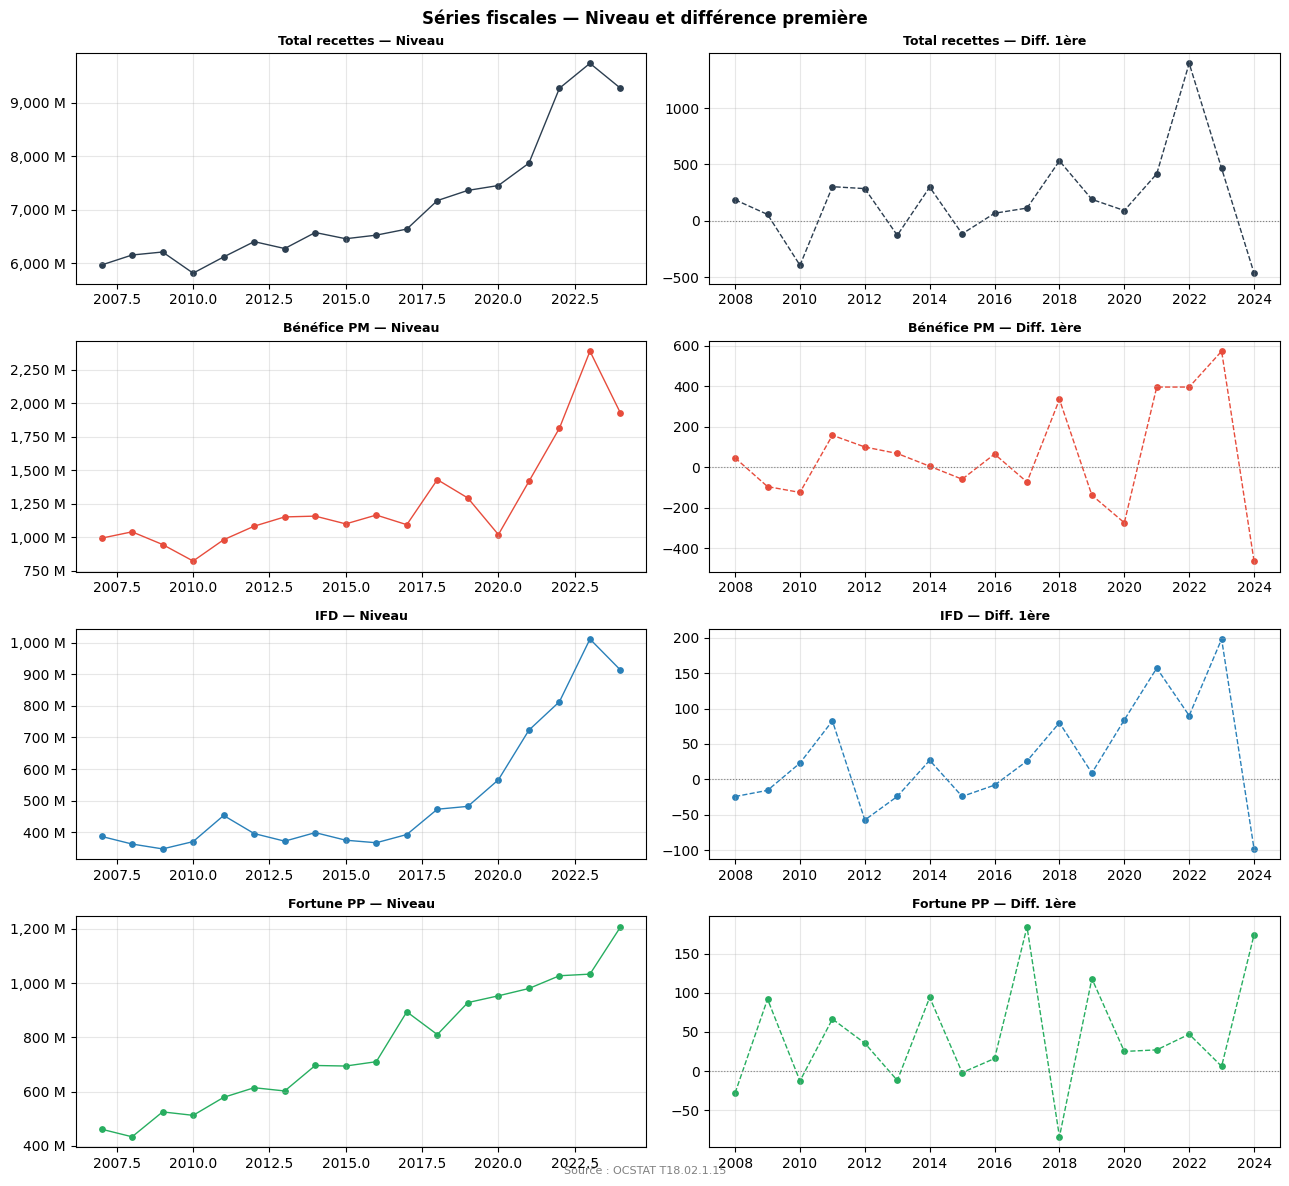

✓ Graphique sauvegardé

SYNTHÈSE — DÉCISIONS POUR LE NOTEBOOK 03

SÉRIES RETENUES :
  Cible principale  : total recettes (I(1) confirmé)
  Proxy IR          : pp_total (cohérent 2007–2024, décision Q7)
  Fortune           : EXCLUE des régresseurs (corr. diff = 0.05)
  Successions       : exclues (volatilité + outlier Q3)

DUMMIES DISPONIBLES :
  dummy_rffa       (=1 si annee >= 2022) → À INTÉGRER
  dummy_covid      (=1 si annee == 2020) → non significative
  dummy_succ_2009  (=1 si annee == 2009) → en réserve

MODÈLES À CONSTRUIRE DANS LE NOTEBOOK 03 :
  Étape 1 : ARIMA baseline (d=1 forcé par Q1)
  Étape 2 : ETS — comparaison avec ARIMA
  Étape 3 : ARIMAX — ARIMA + dummy_rffa
  Étape 4 : VAR en différences (décision Q4)

→ Chaque modèle sera motivé par les résultats du précédent.

✓ Données sauvegardées — notebook 02 terminé


In [9]:
# =============================================================================
# 5. GRAPHIQUE — SÉRIES EN NIVEAU ET EN DIFFÉRENCE
# =============================================================================

fig, axes = plt.subplots(4, 2, figsize=(13, 12))

series_graph = {
    'Total recettes' : (df['total'],    '#2C3E50'),
    'Bénéfice PM'    : (df['ben_pm'],   '#E74C3C'),
    'IFD'            : (df['ifd'],      '#2980B9'),
    'Fortune PP'     : (df['fortune'],  '#27AE60')
}

for i, (nom, (serie, couleur)) in enumerate(series_graph.items()):
    # Niveau
    ax_niv = axes[i, 0]
    ax_niv.plot(df['annee'], serie, color=couleur, linewidth=1)
    ax_niv.scatter(df['annee'], serie, color=couleur, s=15)
    ax_niv.set_title(f"{nom} — Niveau", fontweight='bold', fontsize=9)
    ax_niv.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f} M"))
    ax_niv.grid(True, alpha=0.3)

    # Différence première
    ax_dif = axes[i, 1]
    diff = serie.diff().dropna()
    ax_dif.plot(df['annee'].iloc[1:], diff,
                color=couleur, linewidth=1, linestyle='dashed')
    ax_dif.scatter(df['annee'].iloc[1:], diff, color=couleur, s=15)
    ax_dif.axhline(y=0, color='grey', linestyle='dotted', linewidth=0.8)
    ax_dif.set_title(f"{nom} — Diff. 1ère", fontweight='bold', fontsize=9)
    ax_dif.grid(True, alpha=0.3)

plt.suptitle("Séries fiscales — Niveau et différence première",
             fontweight='bold', fontsize=12)
fig.text(0.5, 0.01, "Source : OCSTAT T18.02.1.15",
         ha='center', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../figures/02_stationnarite_visuelle_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

# =============================================================================
# SYNTHÈSE FINALE — DÉCISIONS POUR LE NOTEBOOK 03
# =============================================================================

print("\n" + "=" * 60)
print("SYNTHÈSE — DÉCISIONS POUR LE NOTEBOOK 03")
print("=" * 60)

print("""
SÉRIES RETENUES :
  Cible principale  : total recettes (I(1) confirmé)
  Proxy IR          : pp_total (cohérent 2007–2024, décision Q7)
  Fortune           : EXCLUE des régresseurs (corr. diff = 0.05)
  Successions       : exclues (volatilité + outlier Q3)

DUMMIES DISPONIBLES :
  dummy_rffa       (=1 si annee >= 2022) → À INTÉGRER
  dummy_covid      (=1 si annee == 2020) → non significative
  dummy_succ_2009  (=1 si annee == 2009) → en réserve

MODÈLES À CONSTRUIRE DANS LE NOTEBOOK 03 :
  Étape 1 : ARIMA baseline (d=1 forcé par Q1)
  Étape 2 : ETS — comparaison avec ARIMA
  Étape 3 : ARIMAX — ARIMA + dummy_rffa
  Étape 4 : VAR en différences (décision Q4)

→ Chaque modèle sera motivé par les résultats du précédent.
""")

# Sauvegarde finale
df.to_csv('../data/df_fiscal.csv', index=False)
print("✓ Données sauvegardées — notebook 02 terminé")